In [10]:
import numpy as np
import matplotlib.pyplot as plt





from matplotlib import rc
 

rc('font',**{'family':'sans-serif','sans-serif':['Fira Sans'],'size':14,'style':'normal'})
rc('text', usetex=False)


BLUE = 'xkcd:pastel blue'
RED = 'xkcd:pastel red'
GREEN = 'xkcd:pastel green'
YELLOW ='xkcd:pastel pink'
PURPLE = 'xkcd:pastel purple'
DBLUE = 'xkcd:light navy blue'
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[BLUE, RED, GREEN, YELLOW,PURPLE,DBLUE])


In [11]:
# def ramsey_H(f, Omega, T):
#     lowpass = (Omega**2 / (Omega**2 - (2*np.pi*f)**2))**2
#     sinc_term = np.sin(np.pi*f*T) / (np.pi*f*T)
#     edge_term = 2/(Omega*T) * np.cos(np.pi**2*f/Omega + np.pi*f*T)

#     return T**2 * (sinc_term + edge_term)**2 * lowpass


def ramsey_H(f, Omega, T):
    numerator = (
        np.sin(np.pi*f*T)
        + (2*f/(np.pi*Omega))*np.cos(np.pi*f*(np.pi + T*Omega)/Omega)
    )
    return (numerator / (np.pi*f))**2 * (Omega**2 / (Omega**2 - (2*np.pi*f)**2))**2

def ramsey_H_no_edge(f, Omega, T):
    numerator = (
        np.sin(np.pi*f*T))
    return (numerator / (np.pi*f))**2 * (Omega**2 / (Omega**2 - (2*np.pi*f)**2))**2

def noise_psd(f,B):
    return (2*np.pi*f)**2/((2*np.pi*f)**2+B**2)

In [63]:
f = np.linspace(5,1000,10000)
f0 = 100
Omega = 2*np.pi*f0
T = 100
B = 10000

In [64]:
Omega2 = -2/T*np.arctan(np.pi/2)+2e2*np.pi

In [65]:
Omega2/(2*np.pi)

np.float64(99.99680453536615)

(1e-15, 10000)

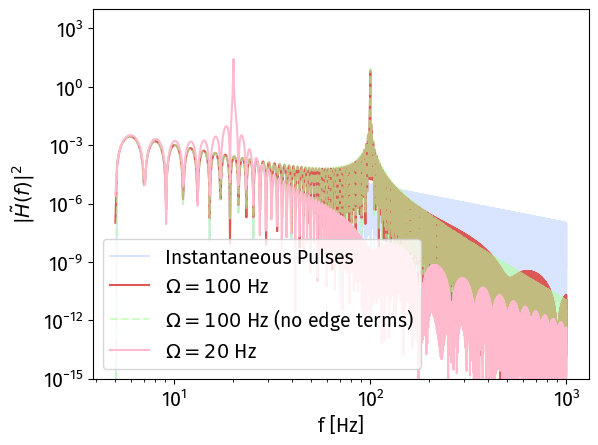

In [67]:
plt.plot(f,ramsey_H(f,1e10,T),alpha = 0.4,label = 'Instantaneous Pulses')
plt.plot(f,ramsey_H(f,Omega,T),alpha = 1,label = '$\Omega = 100$ Hz')
plt.plot(f,ramsey_H_no_edge(f,Omega,T),'--',alpha = 0.6,label = '$\Omega = 100$ Hz (no edge terms)')
plt.plot(f,ramsey_H(f,Omega/5,T),alpha = 1,label = '$\Omega = 20$ Hz')


plt.ylabel(r'$|\tilde{H}(f)|^2$')
plt.xlabel('f [Hz]')
plt.yscale('log')
plt.xscale('log')
plt.legend(loc = 'lower left')

plt.ylim([1e-15,10000])

# plt.savefig('plots/rabi_freq_laser_noise.pdf')

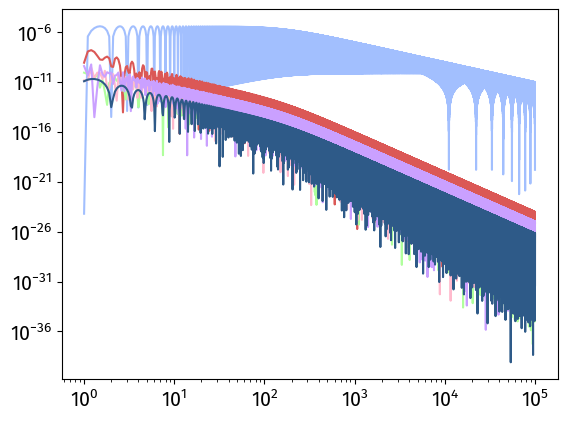

In [71]:
B = 1000
f = np.linspace(1,100000,1000000)
# plt.plot(f,noise_psd(f,B))

# plt.plot(f,ramsey_H(f,1e4/(np.pi*2),1)*noise_psd(f,B))
# plt.plot(f,ramsey_H(f,1e5/(np.pi*2),1)*noise_psd(f,B))
plt.plot(f,ramsey_H(f,1e10/(np.pi*2),1)*noise_psd(f,B))
# plt.plot(f,ramsey_H(f,100/(np.pi*2),1)*noise_psd(f,B))
plt.plot(f,ramsey_H(f,12/(np.pi*2),1)*noise_psd(f,B))
plt.plot(f,ramsey_H(f,2/(np.pi*2),1)*noise_psd(f,B))
plt.plot(f,ramsey_H(f,3/(np.pi*2),1)*noise_psd(f,B))
plt.plot(f,ramsey_H(f,4/(np.pi*2),1)*noise_psd(f,B))
plt.plot(f,ramsey_H(f,1/(np.pi*2),1)*noise_psd(f,B))
plt.yscale('log')
plt.xscale('log')




In [78]:
np.sum(ramsey_H(f,100/(np.pi*2),1)*noise_psd(f,B))

np.float64(0.006433294723042838)

np.float64(2149.9572322751633)

In [36]:


np.sum(ramsey_H(f,10,1)*noise_psd(f,B))

np.float64(0.026246691902568828)

In [94]:
np.sum(ramsey_H(f,,T)*noise_psd(f,B))

np.float64(0.004974978943144213)

In [69]:
from tqdm.notebook import trange, tqdm
f = np.linspace(1,100000,10000000)
B = 1000
noise = []
T = 1
rabis = np.linspace(10/(np.pi*2),100/(np.pi*2),100)
for rabi in tqdm(rabis):
    noise.append(np.sum(ramsey_H(f,rabi,T)*noise_psd(f,B))/np.sum(ramsey_H(f,1e10,T)*noise_psd(f,B)))

  0%|          | 0/100 [00:00<?, ?it/s]

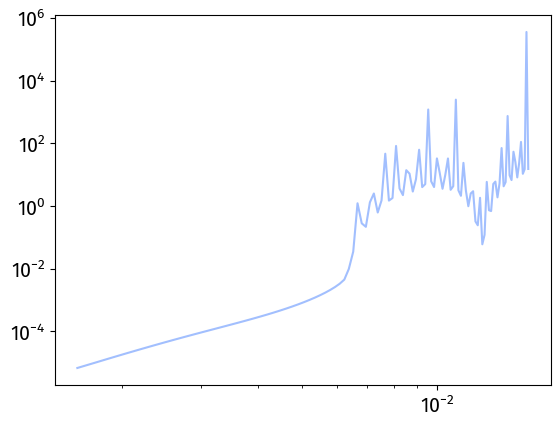

In [72]:
plt.plot(rabis/B,noise)
plt.yscale('log')
plt.xscale('log')

In [2]:
def Hf_max(omega,T):
    num = np.pi*np.cos(omega*T/2)+2*np.sin(omega*T/2)
    den = 2*omega
    return (num/den)**2

In [7]:
T = 100
omega = np.logspace(0,1,10000)

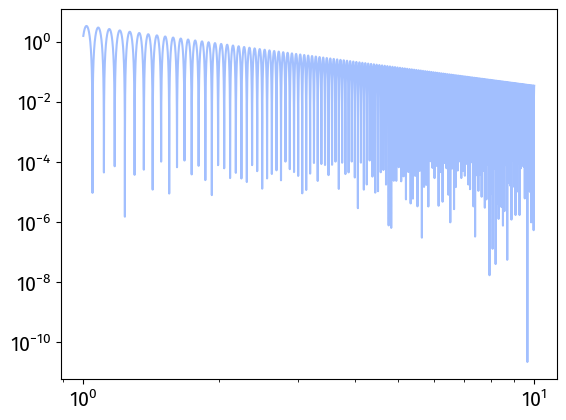

In [9]:
plt.plot(omega,Hf_max(omega,T))
plt.xscale('log')
plt.yscale('log')